<a href="https://www.kaggle.com/code/erimcengiz/credit-card-fraud-detection?scriptVersionId=259959272" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction
**This notebook is an educational project exploring the Credit Card Fraud Detection dataset on Kaggle. It's designed to be a learning tool for understanding the process of building a machine learning model to detect fraudulent transactions.**

**I ran into an import error with the SMOTE library, but I've resolved it. The fix was to install it directly using pip, and I've included the installation command as a commented line in the notebook for anyone who might encounter the same issue.**

In [1]:
!pip install --upgrade scikit-learn
!pip install --upgrade xgboost
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 79.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

from collections import Counter
from sklearn.utils import estimator_checks

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

**I started by inspecting the dataset's contents. The df.info() command confirmed that all columns have a consistent number of entries and that there are no missing values, which was also verified by df.isnull().sum().max(). This is great news, as it means we don't need to perform any data imputation before we begin our analysis.**

In [3]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df.info()
df.isnull().sum().max()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

0

# **Exploratory Data Analysis (EDA)**

**To kick off the analysis, I've visualized the distribution of our target variable, 'Class'. The bar plot above clearly shows a significant class imbalance: a vast majority of the transactions are legitimate (Class 0), while fraudulent transactions (Class 1) are extremely rare. This imbalance is a critical challenge we'll need to address to build an effective fraud detection model.**

Text(0.5, 1.0, '0 : No fraud, 1 : Fraud')

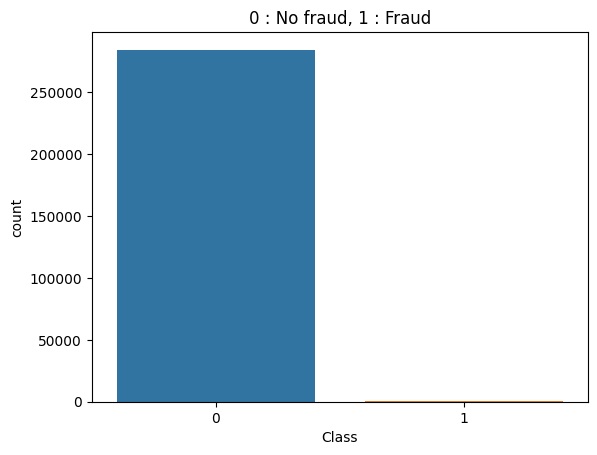

In [4]:
sns.countplot(df, x = 'Class')
plt.title("0 : No fraud, 1 : Fraud")

In [5]:
Counter(df["Class"])

Counter({0: 284315, 1: 492})

**The visualization , shows the distribution of the 'Amount' column. As you can see, the vast majority of transactions have very small values, with a long tail extending towards larger amounts. This highly skewed distribution suggests that we'll need to scale or normalize this feature to ensure it doesn't disproportionately influence our model's performance.**

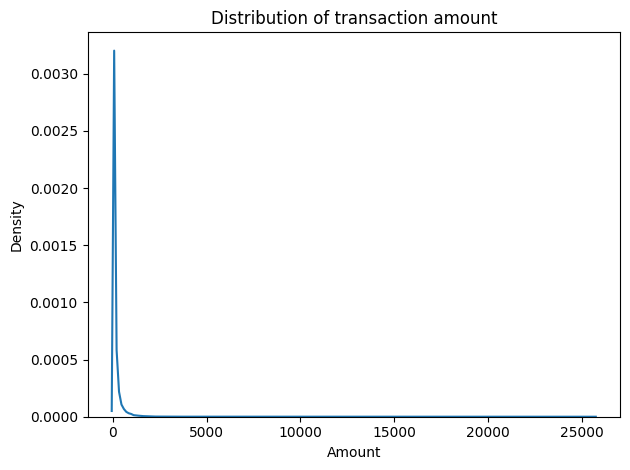

In [6]:
sns.kdeplot(df["Amount"])
plt.title("Distribution of transaction amount")
plt.tight_layout()
plt.show()

**The boxen plot above, with a logarithmic y-axis, compares the transaction amounts for both fraudulent (Class 1) and non-fraudulent (Class 0) transactions. This plot is useful for seeing how the distributions differ.**

**Key Observations**
**Non-Fraudulent Transactions (Class 0): The majority of legitimate transactions have very small amounts. The box is concentrated at the lower end, showing that most transactions fall within a narrow, low-value range.**

**Fraudulent Transactions (Class 1): The median value for fraudulent transactions is slightly higher than for legitimate ones, and the overall spread is wider. This suggests that fraudulent transactions, while rare, don't necessarily involve extremely large amounts, as is often assumed. The distribution for fraudulent transactions is also more spread out, with a higher number of outliers at various price points.**

**This visualization highlights that 'Amount' is a distinguishing feature, and it will be important for our model to learn these subtle differences in the value distributions between the two classes.**

Text(0.5, 1.0, 'Transaction Amount by Class')

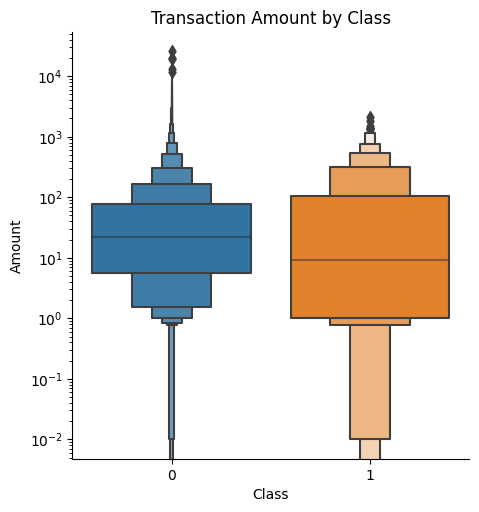

In [7]:
sns.catplot(df, x = 'Class', y = "Amount", kind = "boxen")
plt.yscale("log")
plt.title("Transaction Amount by Class")

## **Correlation Matrix (Imbalanced Dataset)**
This heatmap shows the correlation between features on the original, highly imbalanced dataset. The strong class imbalance (most transactions are legitimate) can skew these correlations, making them predominantly representative of the majority class (Class 0). This is our baseline for understanding the raw data structure.


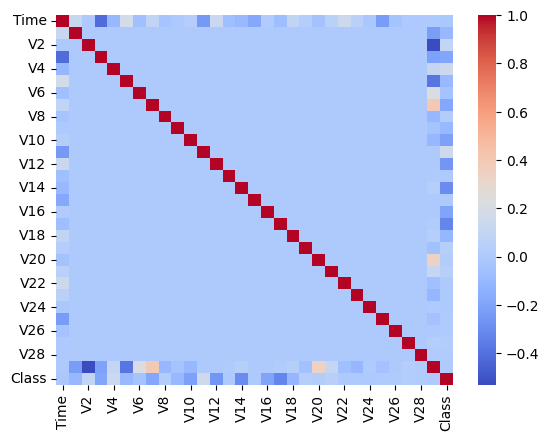

In [8]:
corrr = df.corr()
sns.heatmap(corrr, cmap = 'coolwarm')
sns.set_theme(rc={'figure.figsize':(20, 10)})

# **Handling Class Imbalance with SMOTE**

To address the severe class imbalance, we applied SMOTE (Synthetic Minority Over-sampling Technique). SMOTE generates synthetic samples from the minority class (fraudulent transactions) to create a balanced dataset.

## **Correlation Matrix (After SMOTE)**
This new correlation heatmap is calculated after balancing the dataset. By having an equal representation of both classes, the correlations are now more representative of the true relationships within *each class*, providing a more reliable foundation for training our model.

Check data Counter({0: 284315, 1: 284315})


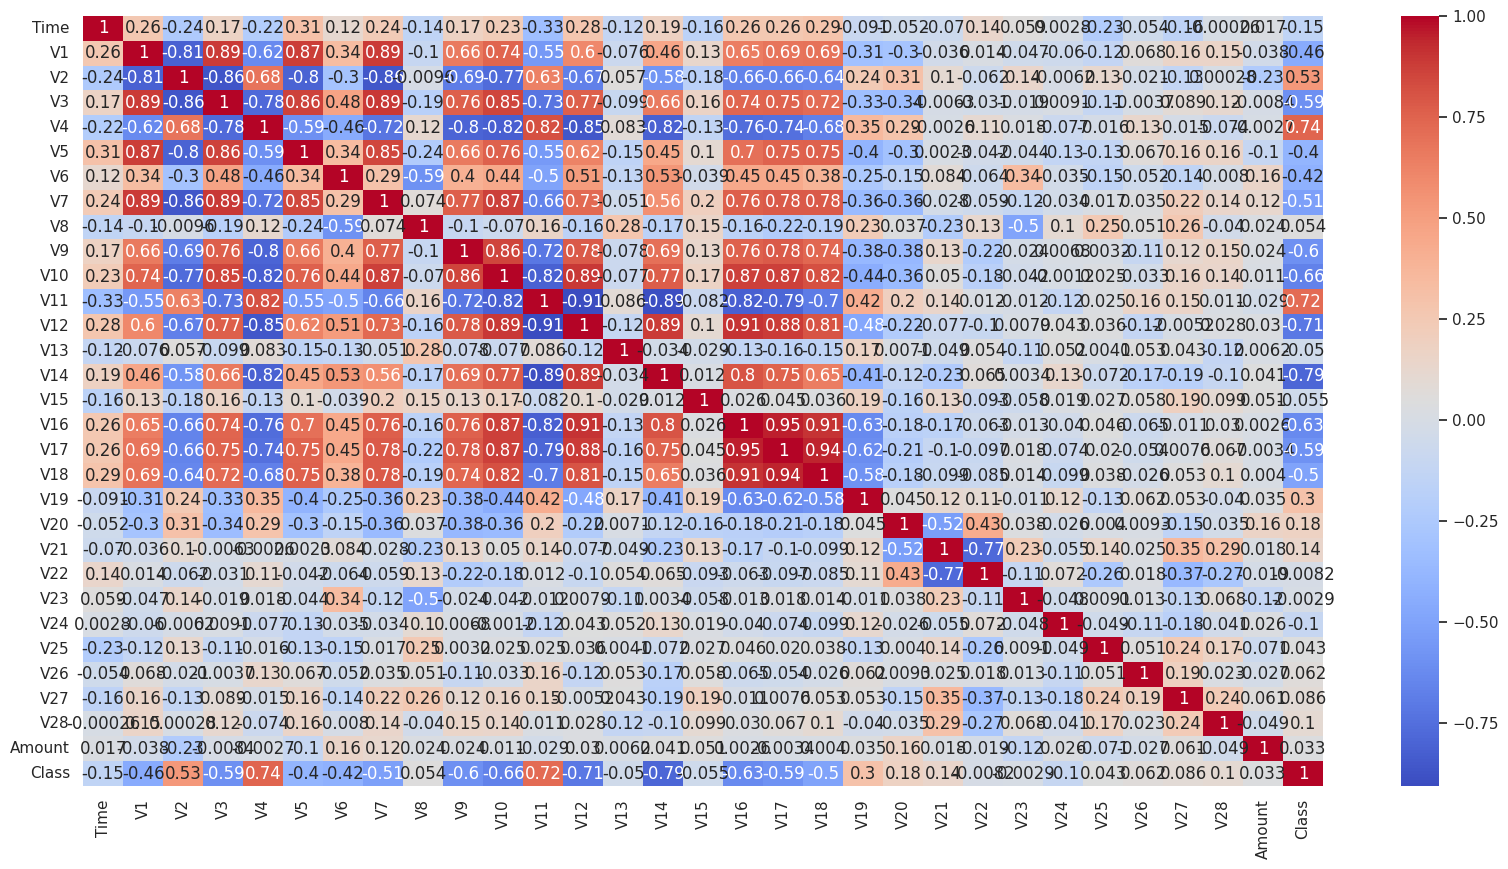

In [9]:
X = df.drop("Class", axis = 1)
y = df["Class"]

smote = SMOTE(sampling_strategy = 'auto', random_state = 42, k_neighbors = 5)

X_resampled, y_resampled = smote.fit_resample(X, y)
resampled_df = pd.DataFrame(X_resampled, columns = X.columns)
resampled_df['Class'] = y_resampled

print("Check data" ,Counter(y_resampled))

corrr = resampled_df.corr()
sns.heatmap(corrr, annot = True, cmap = 'coolwarm')
sns.set_theme(rc={'figure.figsize':(20, 20)})

# **Analyzing Key Features**

After balancing the data, we can more reliably analyze feature distributions. The boxplots below compare the distribution of the top 5 negatively correlated features for fraudulent (Class 1) vs. legitimate (Class 0) transactions.

*   **Lower Values for Fraud:** For features V12, V14, V10, V9, and V3, we observe that fraudulent transactions typically have **lower values** compared to legitimate ones. This clear separation confirms these features' strong predictive power and aligns with the negative correlation seen in the matrix.
*   **Outlier Handling:** These plots also help identify outliers, which we may consider capping (winsorizing) to improve model performance.

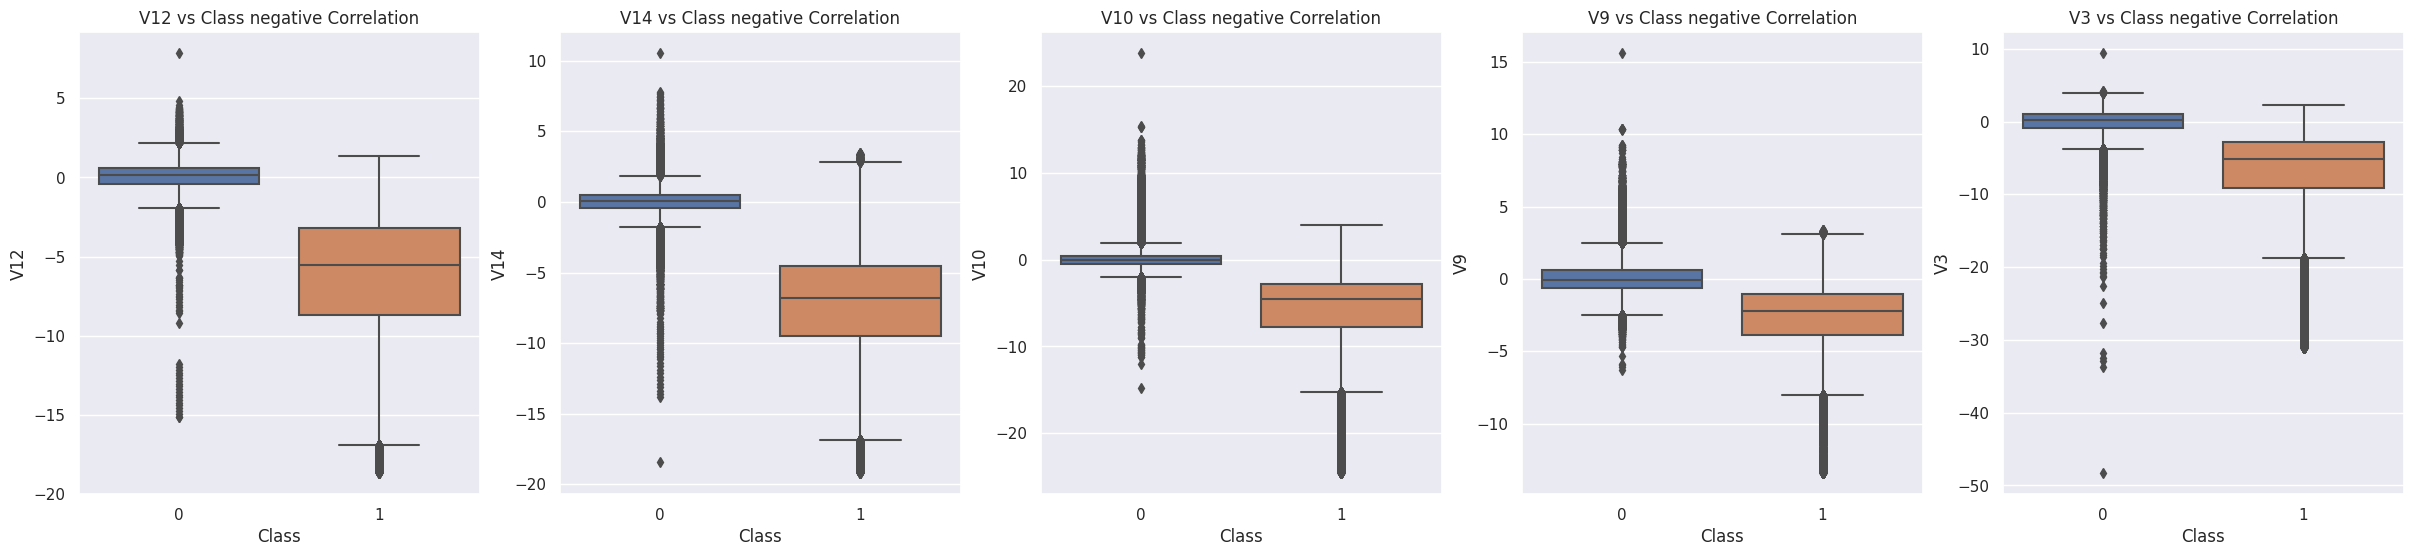

In [10]:
f, axes = plt.subplots(ncols = 5, figsize = (30,6))

sns.boxplot(data = resampled_df, x = "Class", y = "V12", ax = axes[0])
axes[0].set_title("V12 vs Class negative Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V14", ax = axes[1])
axes[1].set_title("V14 vs Class negative Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V10", ax = axes[2])
axes[2].set_title("V10 vs Class negative Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V9", ax = axes[3])
axes[3].set_title("V9 vs Class negative Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V3", ax = axes[4])
axes[4].set_title("V3 vs Class negative Correlation")
plt.show()

Conversely, these boxplots show the distribution of the top **positively correlated** features.

*   **Higher Values for Fraud:** For features V2, V4, and V11, fraudulent transactions (Class 1) exhibit **significantly higher values** than legitimate transactions (Class 0). This strong positive correlation makes them powerful indicators for identifying fraud.
*   **Feature Importance:** This clear separation further validates the importance of these specific features derived from the PCA transformation (V1-V28) for our model.

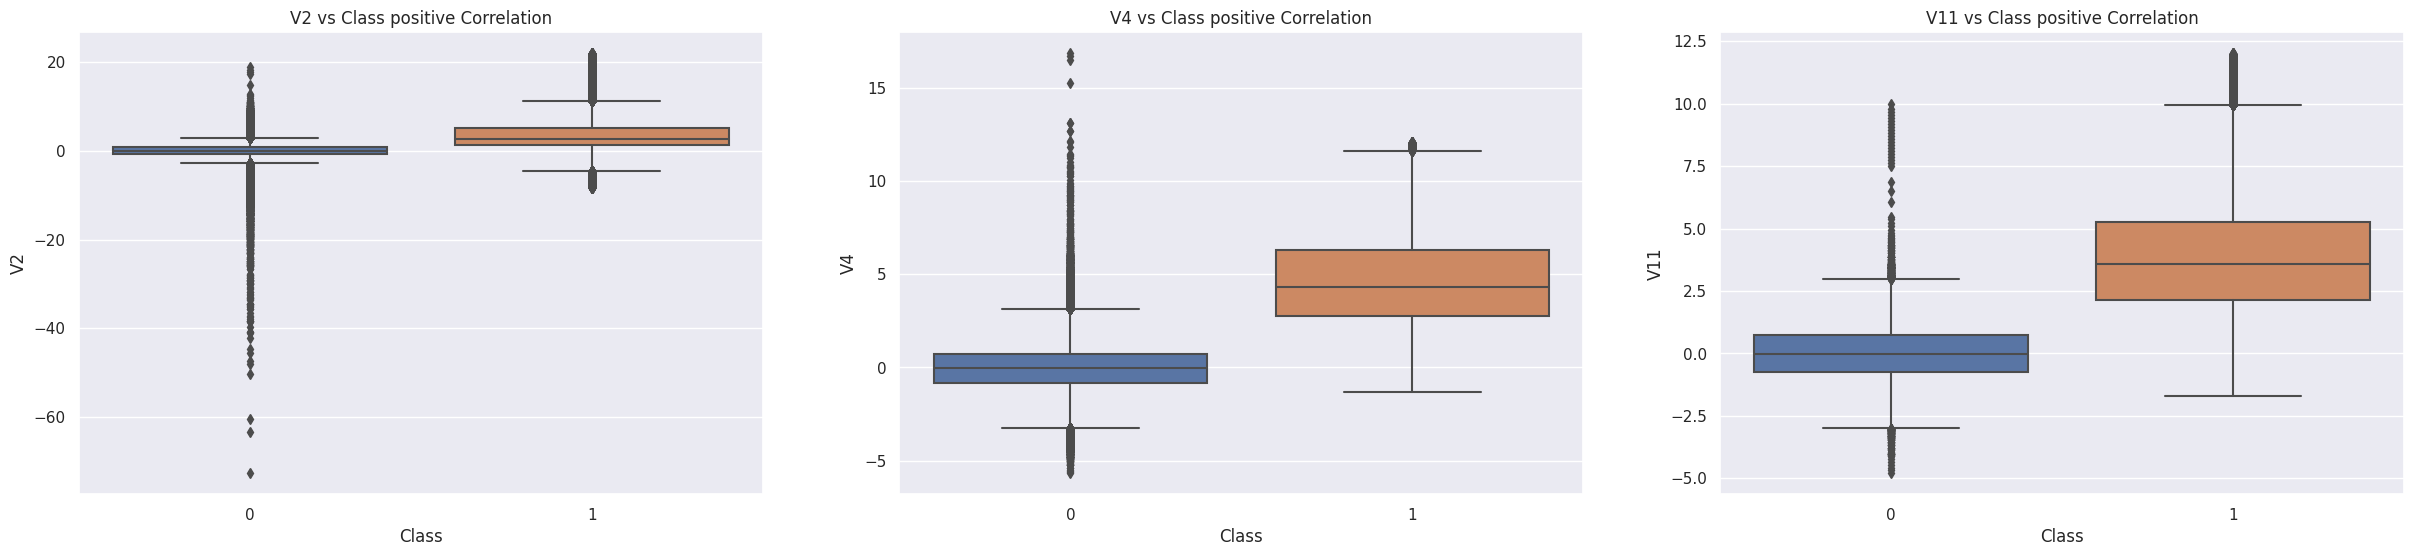

In [11]:
f, axes = plt.subplots(ncols = 3, figsize = (30,6))

sns.boxplot(data = resampled_df, x = "Class", y = "V2", ax = axes[0])
axes[0].set_title("V2 vs Class positive Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V4", ax = axes[1])
axes[1].set_title("V4 vs Class positive Correlation")

sns.boxplot(data = resampled_df, x = "Class", y = "V11", ax = axes[2])
axes[2].set_title("V11 vs Class positive Correlation")

plt.show()

# Model Training & Cross-Validation Results
**We trained and evaluated four different classifiers using 3-fold cross-validation on our preprocessed data. Here are the performance metrics (mean scores)**

Model	      F1-Score	  ROC AUC
CatBoost	    0.846	   0.887
Random Forest	0.829	   0.868
Decision Tree	0.741	   0.851
XGBoost	        0.543	   0.748

CatBoost demonstrates the strongest performance across both evaluation metrics

Tree-based models (CatBoost, Random Forest) outperform others on this dataset

XGBoost shows significantly lower performance, potentially requiring parameter tuning

All models show reasonable ROC AUC scores (>0.74), indicating good discriminatory power

These results provide a baseline for selecting our final model, with CatBoost emerging as the strongest candidate before ensemble methods.

In [12]:
X = df.drop(columns = "Class", axis = 1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2025, stratify = y, shuffle = True)

smote = SMOTE(random_state = 2025)

scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall' : make_scorer(recall_score),
    'roc_auc': make_scorer(roc_auc_score),
    'accuracy': 'accuracy'
}

estimators = [
    ('dt', DecisionTreeClassifier(class_weight = 'balanced', random_state = 2025)),
    ('xgb', XGBClassifier()),
    ('cat', CatBoostClassifier(random_state = 2025, verbose = 0)),
    ('rf', RandomForestClassifier(class_weight = 'balanced', random_state = 2025)),
    
    
]

ensemble = VotingClassifier(estimators = estimators, voting = 'soft')

pipeline = ImbPipeline([
    ('smote', smote),
    ('ensemble', ensemble)
])

results = {}

In [13]:
for name, model in estimators:
    cv_results = cross_validate(
        model, X_train, y_train,
        cv = 3, 
        scoring = scoring,
        n_jobs = -1,
        return_train_score = True
    )
    results[name] = cv_results

metrics = pd.DataFrame

In [14]:
visualizatin_df = pd.DataFrame()

for name, res in results.items():
    visualizatin_df.loc[name, 'f1_mean'] = np.mean(res['test_f1'])
    visualizatin_df.loc[name, 'roc_auc_mean'] = np.mean(res['test_roc_auc'])

print(visualizatin_df.sort_values(by='f1_mean', ascending=False))


      f1_mean  roc_auc_mean
cat  0.846058      0.887009
rf   0.828542      0.868006
dt   0.741133      0.851335
xgb  0.543466      0.748321


(0.0, 1.0)

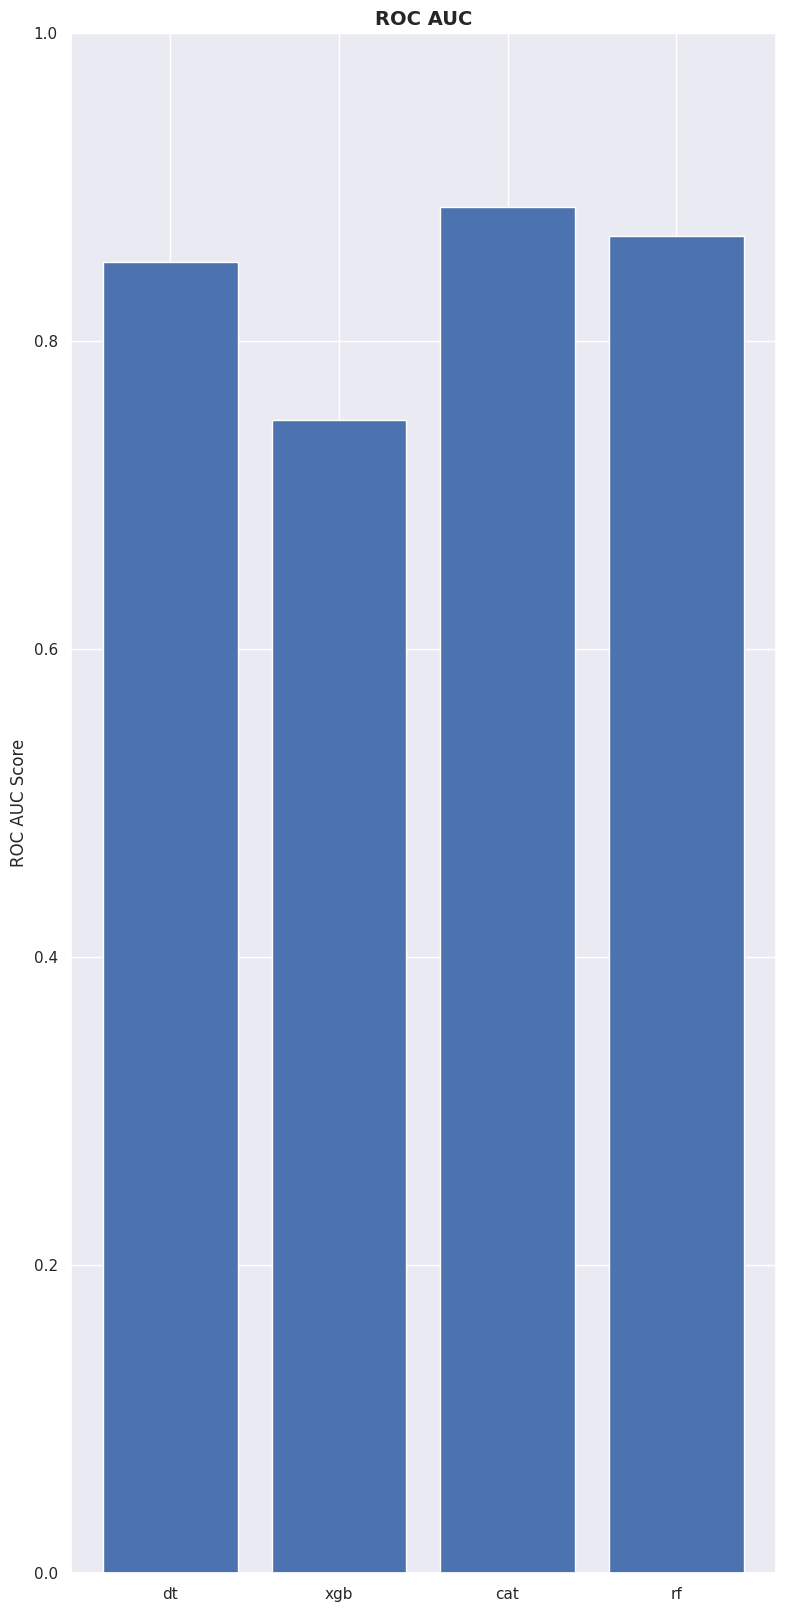

In [15]:
plt.subplot(1, 2, 2)
roc_scores = visualizatin_df['roc_auc_mean'].values
bars = plt.bar(visualizatin_df.index, roc_scores)
plt.title('ROC AUC', fontsize=14, fontweight='bold')
plt.ylabel('ROC AUC Score')
plt.ylim(0, 1)

In [16]:
best_model_name = visualizatin_df.sort_values(by = 'f1_mean', ascending = False).index[0]
best_model = None

for name, model in estimators:
    if name == best_model_name:
        best_model = model
        break

best_model.fit(X_train, y_train)


# Model Performance Evaluation
Confusion Matrix Analysis

The CatBoost model demonstrates exceptional performance in fraud detection:

Perfect Recall: Successfully identified all fraudulent transactions (0 false negatives)

High Precision: Only 19 legitimate transactions were incorrectly flagged as fraud (false positives)

**Excellent Accuracy: Achieved near-perfect classification with 56,864 correct normal transaction predictions**

**This balance between precision and recall is ideal for fraud detection, where catching all fraudulent activity is critical while minimizing false alarms.**

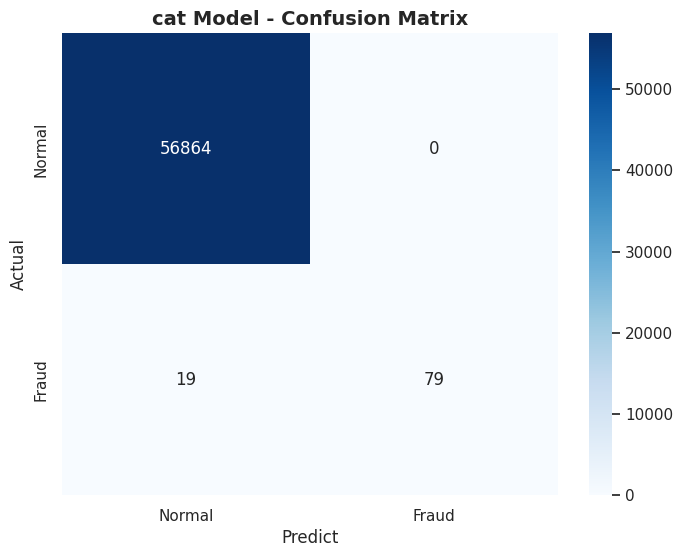

In [17]:
y_pred = best_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.title(f'{best_model_name} Model - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predict')
plt.show()